In [1]:
import sys, os, glob, time
import numpy as np
import matplotlib.pyplot as plt

for _pattern in ("chapter*", "appendix*"):
    for _d in sorted(glob.glob(os.path.join("..", "BookManybody",
                                            "BookPrograms", _pattern))):
        if _d not in sys.path:
            sys.path.insert(0, _d)
import ccdchannels as cc
from quantumdot import QuantumDot, matrices
from coupledcluster import ccd as ccd_dense, reference_energy, mp2_energy

np.set_printoptions(precision=6, suppress=True, linewidth=120)

In [2]:
dot = QuantumDot(2, shells=5)
print("magic numbers:", dot.magic_numbers())
for N in (2, 6, 12, 20):
    dot = QuantumDot(N, shells=5)
    h, v = matrices(5)
    h_hf, v_hf, eps, labels, C, it = cc.hartree_fock_blocks(dot, h, v, N)
    f = np.diag(eps)
    F = h_hf + np.einsum("piqi->pq", v_hf[:, :N, :, :N])
    print(f"N = {N:2d}: E_0 = {np.sum(dot.energies()[:N]):8.4f}, E_ref(osc.) = {reference_energy(h, v, N):12.8f}, "
          f"E_HF = {reference_energy(h_hf, v_hf, N):12.8f} ({it} iterations), "
          f"max |f_ai| = {np.abs(F[N:, :N]).max():.1e}, max |f_pq - eps| = {np.abs(F - f).max():.1e}")

magic numbers: [2, 6, 12, 20, 30, 42]


N =  2: E_0 =   2.0000, E_ref(osc.) =   3.25331414, E_HF =   3.16192140 (15 iterations), max |f_ai| = 1.2e-15, max |f_pq - eps| = 4.4e-15
N =  6: E_0 =  10.0000, E_ref(osc.) =  22.21981284, E_HF =  20.72025707 (24 iterations), max |f_ai| = 2.4e-15, max |f_pq - eps| = 1.4e-14


N = 12: E_0 =  28.0000, E_ref(osc.) =  73.76554905, E_HF =  67.29686927 (30 iterations), max |f_ai| = 3.8e-15, max |f_pq - eps| = 2.0e-14
N = 20: E_0 =  60.0000, E_ref(osc.) = 177.96329742, E_HF = 161.33972067 (25 iterations), max |f_ai| = 4.9e-15, max |f_pq - eps| = 1.6e-14


In [3]:
for shells in (1, 2):
    dot = QuantumDot(2, shells)
    h, v = matrices(shells)
    h_hf, v_hf, eps, labels, C, it = cc.hartree_fock_blocks(dot, h, v, 2)
    f = np.diag(eps)
    t0 = time.time(); naive = cc.ccd_naive(eps, v_hf, 2); t_naive = time.time() - t0
    t0 = time.time(); dense = ccd_dense(f, v_hf, 2); t_dense = time.time() - t0
    exact = cc.two_electron_spectrum(h, v)[0]
    E_hf = reference_energy(h_hf, v_hf, 2)
    print(f"shells 0-{shells}, {h.shape[0]} spin-orbitals: E_HF = {E_hf:.8f}")
    print(f"   naive loops : E_corr = {naive['energy']:.12f}   {t_naive:7.2f} s for {naive['iterations']} iterations")
    print(f"   dense einsum: E_corr = {dense['energy']:.12f}   {t_dense:7.3f} s")
    print(f"   two-electron FCI: {exact:.8f};  E_HF + E_CCD = {E_hf + naive['energy']:.8f}")

shells 0-1, 6 spin-orbitals: E_HF = 3.25331414
   naive loops : E_corr = -0.100986130200      0.27 s for 14 iterations
   dense einsum: E_corr = -0.100986130218     0.002 s
   two-electron FCI: 3.15232801;  E_HF + E_CCD = 3.15232801


shells 0-2, 12 spin-orbitals: E_HF = 3.16269135
   naive loops : E_corr = -0.123643528496      6.28 s for 18 iterations
   dense einsum: E_corr = -0.123643528517     0.010 s
   two-electron FCI: 3.03860458;  E_HF + E_CCD = 3.03904782


In [4]:
results = {}
print(f"{'N':>3s} {'norb':>5s} {'E_HF':>13s} {'E_MP2':>12s} {'E_CCD':>12s} {'|dense - channels|':>18s} "
      f"{'t_channels':>10s} {'t_dense':>8s} {'channels':>9s} {'largest block':>14s}")
for N in (2, 6, 12, 20):
    r = cc.run(N, shells=5)
    results[N] = r
    sizes = sorted(r["channels"].block_sizes.values(), key=lambda s: s[0] * s[1], reverse=True)
    print(f"{N:3d} {r['n_orbitals']:5d} {r['E_HF']:13.8f} {r['E_MP2']:12.8f} {r['E_CCD']:12.8f} "
          f"{abs(r['E_CCD'] - r['E_CCD_dense']):18.1e} {r['t_channels']:10.2f} {r['t_dense']:8.2f} "
          f"{len(sizes):9d} {str(sizes[0]):>14s}")

  N  norb          E_HF        E_MP2        E_CCD |dense - channels| t_channels  t_dense  channels  largest block


  2    42    3.16192140  -0.13488329  -0.14799908            5.6e-17       0.04     1.52         1        (42, 1)


  6    42   20.72025707  -0.41769581  -0.44624450            0.0e+00       0.13     4.70        11        (32, 3)


 12    42   67.29686927  -0.74795401  -0.77019290            0.0e+00       0.38    13.67        23        (23, 8)


 20    42  161.33972067  -0.79449291  -0.74521361            1.1e-16       0.46    12.58        35       (11, 16)


shells 0-3, N =  2:  20 orbitals, E_HF + E_CCD =   3.02527309, channels   0.01 s (22 it.), dense   0.10 s


shells 0-3, N =  6:  20 orbitals, E_HF + E_CCD =  20.42926433, channels   0.05 s (23 it.), dense   0.26 s


shells 0-3, N = 12:  20 orbitals, E_HF + E_CCD =  70.32424919, channels   0.07 s (34 it.), dense   0.39 s


shells 0-4, N =  2:  30 orbitals, E_HF + E_CCD =   3.01794371, channels   0.03 s (23 it.), dense   0.43 s


shells 0-4, N =  6:  30 orbitals, E_HF + E_CCD =  20.33245307, channels   0.08 s (24 it.), dense   1.38 s


...

shells 0-5, N = 20:  42 orbitals, E_HF + E_CCD = 160.59450705, channels   0.44 s (22 it.), dense  12.23 s


shells 0-6, N =  2:  56 orbitals, E_HF + E_CCD =   3.01140528, channels   0.08 s (23 it.), dense   4.61 s


shells 0-6, N =  6:  56 orbitals, E_HF + E_CCD =  20.24984786, channels   0.31 s (26 it.), dense  23.45 s


shells 0-6, N = 12:  56 orbitals, E_HF + E_CCD =  66.04956381, channels   0.85 s (29 it.), dense  57.61 s


shells 0-6, N = 20:  56 orbitals, E_HF + E_CCD = 158.84111858, channels   1.98 s (35 it.), dense 102.27 s


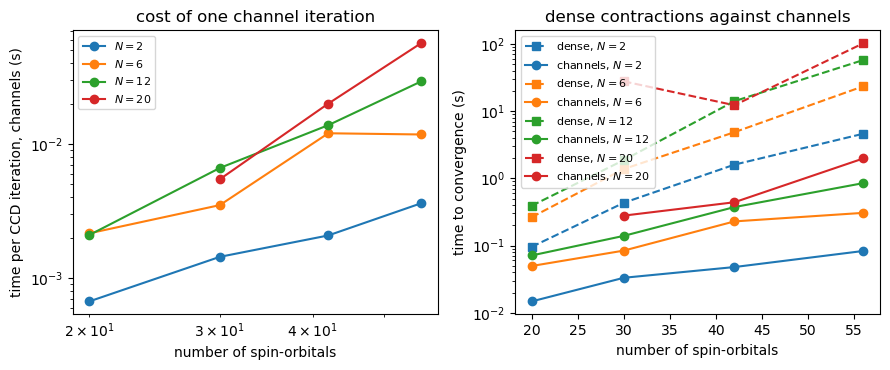

In [5]:
timings = {N: [] for N in (2, 6, 12, 20)}
for shells in (3, 4, 5, 6):
    for N in (2, 6, 12, 20):
        if N >= QuantumDot(N, shells).n_orbitals:      # no empty orbitals: nothing to correlate
            continue
        r = cc.run(N, shells)
        timings[N].append((r["n_orbitals"], r["t_channels"] / r["ccd_iterations"],
                           r["t_dense"], r["E_HF"] + r["E_CCD"], r["E_MP2"], r["E_rCCD"], r["E_RPA"], r["rpa_imag"],
                           r["t_channels"]))
        print(f"shells 0-{shells}, N = {N:2d}: {r['n_orbitals']:3d} orbitals, "
              f"E_HF + E_CCD = {r['E_HF'] + r['E_CCD']:12.8f}, "
              f"channels {r['t_channels']:6.2f} s ({r['ccd_iterations']} it.), dense {r['t_dense']:6.2f} s")

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.8))
for N, rows in timings.items():
    rows = np.array(rows)
    axes[0].loglog(rows[:, 0], rows[:, 1], "o-", label=f"$N={N}$")
axes[0].set_xlabel("number of spin-orbitals")
axes[0].set_ylabel("time per CCD iteration, channels (s)")
axes[0].set_title("cost of one channel iteration")
axes[0].legend(fontsize=8)
for N, rows in timings.items():
    rows = np.array(rows)
    axes[1].semilogy(rows[:, 0], rows[:, 2], "s--", color=f"C{[2, 6, 12, 20].index(N)}", label=f"dense, $N={N}$")
    axes[1].semilogy(rows[:, 0], rows[:, 8], "o-", color=f"C{[2, 6, 12, 20].index(N)}", label=f"channels, $N={N}$")
axes[1].set_xlabel("number of spin-orbitals")
axes[1].set_ylabel("time to convergence (s)")
axes[1].set_title("dense contractions against channels")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

shells 0-3 done (20 orbitals)


shells 0-4 done (30 orbitals)


shells 0-5 done (42 orbitals)


shells 0-6 done (56 orbitals)


shells 0-7 done (72 orbitals)


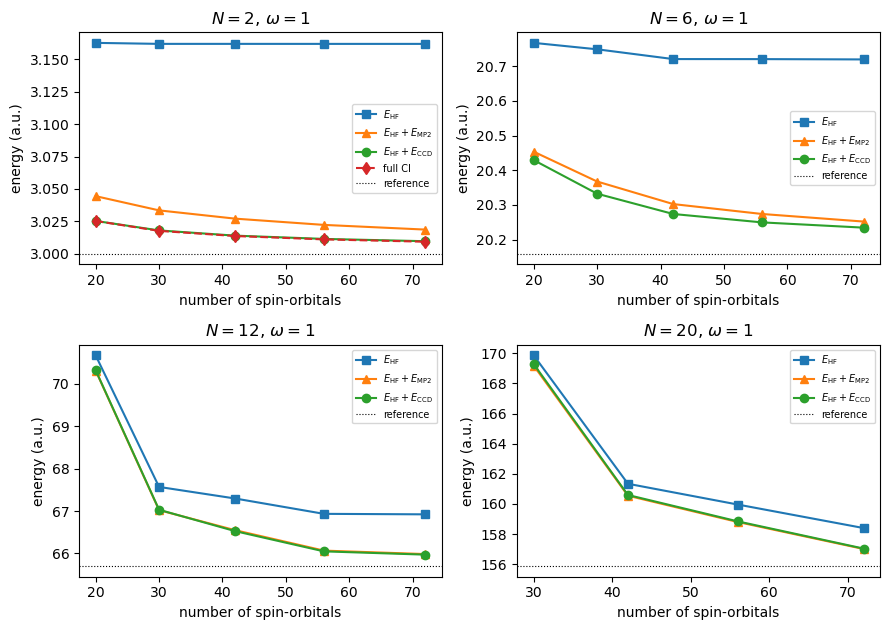

N =  2: 3 shells: 3.02527, 4 shells: 3.01794, 5 shells: 3.01392, 6 shells: 3.01141, 7 shells: 3.00962   (reference 3.0)
N =  6: 3 shells: 20.42926, 4 shells: 20.33245, 5 shells: 20.27401, 6 shells: 20.24985, 7 shells: 20.23470   (reference 20.1597)
N = 12: 3 shells: 70.32425, 4 shells: 67.03110, 5 shells: 66.52668, 6 shells: 66.04956, 7 shells: 65.97216   (reference 65.7)
N = 20: 4 shells: 169.28388, 5 shells: 160.59451, 6 shells: 158.84112, 7 shells: 157.03833   (reference 155.868)


In [6]:
reference = {2: 3.0, 6: 20.1597, 12: 65.700, 20: 155.868}
conv = {N: [] for N in (2, 6, 12, 20)}
for shells in (3, 4, 5, 6, 7):
    h, v = matrices(shells)
    for N in (2, 6, 12, 20):
        if N >= h.shape[0]:
            continue
        r = cc.run(N, shells, dense=False)
        fci = cc.two_electron_spectrum(h, v)[0] if N == 2 else np.nan
        conv[N].append((shells, r["n_orbitals"], r["E_HF"], r["E_HF"] + r["E_MP2"], r["E_HF"] + r["E_CCD"], fci))
    print(f"shells 0-{shells} done ({h.shape[0]} orbitals)")

fig, axes = plt.subplots(2, 2, figsize=(9.0, 6.4))
for ax, N in zip(axes.flat, (2, 6, 12, 20)):
    rows = np.array(conv[N])
    ax.plot(rows[:, 1], rows[:, 2], "s-", label=r"$E_{\rm HF}$")
    ax.plot(rows[:, 1], rows[:, 3], "^-", label=r"$E_{\rm HF}+E_{\rm MP2}$")
    ax.plot(rows[:, 1], rows[:, 4], "o-", label=r"$E_{\rm HF}+E_{\rm CCD}$")
    if N == 2:
        ax.plot(rows[:, 1], rows[:, 5], "d--", label="full CI")
    ax.axhline(reference[N], color="k", lw=0.8, ls=":", label="reference")
    ax.set_xlabel("number of spin-orbitals")
    ax.set_ylabel("energy (a.u.)")
    ax.set_title(f"$N={N}$, $\\omega=1$")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()
for N in (2, 6, 12, 20):
    rows = conv[N]
    print(f"N = {N:2d}: " + ", ".join(f"{int(s)} shells: {e:.5f}" for s, n, ehf, emp2, e, fci in rows)
          + f"   (reference {reference[N]})")

In [7]:
print(f"{'N':>3s} {'E_MP2':>12s} {'E_CCD':>12s} {'E_ring-CCD':>12s} {'E_RPA':>12s} {'Riccati':>9s} "
      f"{'min eig(A-B)':>13s} {'imag.':>6s}")
for N in (2, 6, 12, 20):
    r = results[N]
    print(f"{N:3d} {r['E_MP2']:12.8f} {r['E_CCD']:12.8f} {r['E_rCCD']:12.8f} {r['E_RPA']:12.8f} "
          f"{r['riccati']:9.1e} {r['stability'][0]:13.4f} {r['rpa_imag']:6d}")
r = results[2]
print()
print("two electrons: lowest TDA roots", np.round(r["omega_tda"], 4))
print("               lowest RPA roots", np.round(r["omega_rpa"], 4))
print("               exact excitations", np.round(r["exact"][1:] - r["exact"][0], 4))

  N        E_MP2        E_CCD   E_ring-CCD        E_RPA   Riccati  min eig(A-B)  imag.
  2  -0.13488329  -0.14799908  -0.63822630  -0.63822630   2.1e-12        0.1252      0
  6  -0.41769581  -0.44624450  -1.60760392  -1.60760392   1.4e-12        0.1022      0
 12  -0.74795401  -0.77019290  -2.68578738  -2.68578738   1.5e-12        0.0529      0
 20  -0.79449291  -0.74521361  -2.07136088  -2.07136088   5.1e-13        0.7135      0

two electrons: lowest TDA roots [0.4538 0.4538 0.4538 0.4538 0.4538 0.4538]
               lowest RPA roots [0.3108 0.3108 0.3108 0.3108 0.3108 0.3108]
               exact excitations [0.5838 0.5838 0.5838 0.5838 0.5838]


N = 2, omega =  0.10: E_HF =    0.525666, E_MP2 =  -0.080490, E_CCD =  -0.082523, E_RPA =        nan, min eig(A-B) =  -0.1422, imaginary roots 18


N = 2, omega =  0.25: E_HF =    1.046284, E_MP2 =  -0.103809, E_CCD =  -0.111910, E_RPA =        nan, min eig(A-B) =  -0.1602, imaginary roots 12


N = 2, omega =  0.50: E_HF =    1.799748, E_MP2 =  -0.120364, E_CCD =  -0.131945, E_RPA =        nan, min eig(A-B) =  -0.1020, imaginary roots 12


N = 2, omega =  1.00: E_HF =    3.161921, E_MP2 =  -0.134883, E_CCD =  -0.147999, E_RPA =  -0.638226, min eig(A-B) =   0.1252, imaginary roots 0


N = 2, omega =  2.00: E_HF =    5.677282, E_MP2 =  -0.146932, E_CCD =  -0.159731, E_RPA =  -0.494711, min eig(A-B) =   0.7378, imaginary roots 0


N = 6, omega =  0.10: E_HF =    3.870617, E_MP2 =  -0.254280, E_CCD =  -0.272744, E_RPA =        nan, min eig(A-B) =  -0.1716, imaginary roots 66


N = 6, omega =  0.25: E_HF =    7.391786, E_MP2 =  -0.329524, E_CCD =  -0.354568, E_RPA =        nan, min eig(A-B) =  -0.1854, imaginary roots 30


N = 6, omega =  0.50: E_HF =   12.271499, E_MP2 =  -0.378620, E_CCD =  -0.407402, E_RPA =        nan, min eig(A-B) =  -0.1241, imaginary roots 24


N = 6, omega =  1.00: E_HF =   20.720257, E_MP2 =  -0.417696, E_CCD =  -0.446245, E_RPA =  -1.607604, min eig(A-B) =   0.1022, imaginary roots 0


N = 6, omega =  2.00: E_HF =   35.672333, E_MP2 =  -0.447004, E_CCD =  -0.472025, E_RPA =  -1.320571, min eig(A-B) =   0.7043, imaginary roots 0


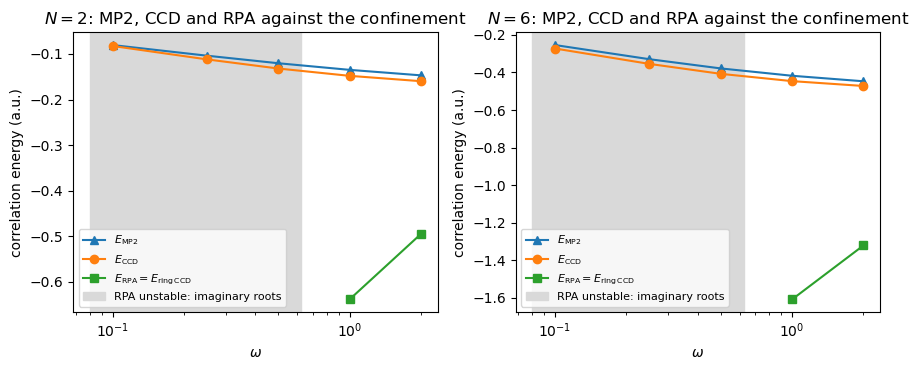

In [8]:
omegas = (0.1, 0.25, 0.5, 1.0, 2.0)
scan = {N: [] for N in (2, 6)}
for N in (2, 6):
    for hw in omegas:
        r = cc.run(N, 5, hw=hw, dense=False)
        scan[N].append((hw, r["E_HF"], r["E_MP2"], r["E_CCD"], r["E_RPA"], r["rpa_imag"], r["stability"][0]))
        print(f"N = {N}, omega = {hw:5.2f}: E_HF = {r['E_HF']:11.6f}, E_MP2 = {r['E_MP2']:10.6f}, "
              f"E_CCD = {r['E_CCD']:10.6f}, E_RPA = {r['E_RPA']:10.6f}, "
              f"min eig(A-B) = {r['stability'][0]:8.4f}, imaginary roots {r['rpa_imag']}")

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.8))
for ax, N in zip(axes, (2, 6)):
    rows = np.array(scan[N])
    ax.semilogx(rows[:, 0], rows[:, 2], "^-", label=r"$E_{\rm MP2}$")
    ax.semilogx(rows[:, 0], rows[:, 3], "o-", label=r"$E_{\rm CCD}$")
    ax.semilogx(rows[:, 0], rows[:, 4], "s-", label=r"$E_{\rm RPA}=E_{\rm ring\,CCD}$")
    unstable = rows[rows[:, 5] > 0, 0]
    if len(unstable):
        ax.axvspan(0.8 * unstable.min(), 1.25 * unstable.max(), color="0.85",
                   label="RPA unstable: imaginary roots")
    ax.set_xlabel(r"$\omega$")
    ax.set_ylabel("correlation energy (a.u.)")
    ax.set_title(f"$N={N}$: MP2, CCD and RPA against the confinement")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()